In [1]:
!pip install PyWavelets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.interpolate import interp1d
from scipy.signal import welch
from scipy.integrate import trapezoid


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


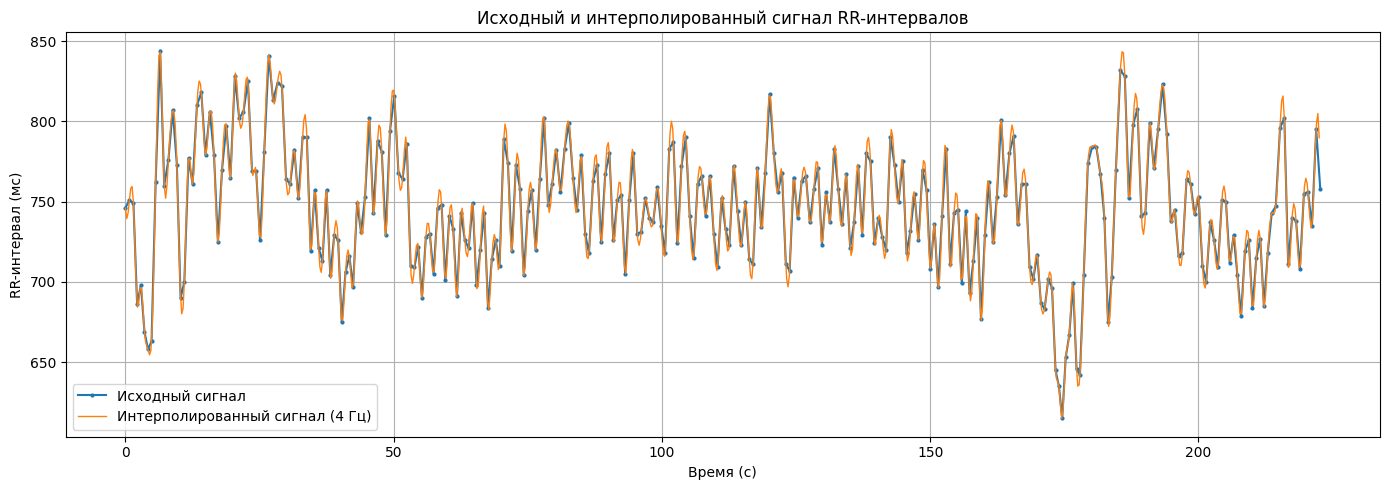

In [2]:
data = pd.read_csv('1_f.csv', header=None)
rr = data[0].values.astype(float)

t_cumsum = np.cumsum(rr) / 1000.0
t_cumsum = t_cumsum - t_cumsum[0]

D = 4
t_uniform = np.arange(t_cumsum[0], t_cumsum[-1], 1.0 / D)

interp_func = interp1d(t_cumsum, rr, kind='cubic')
signal_interp = interp_func(t_uniform)

plt.figure(figsize=(14, 5))
plt.plot(t_cumsum, rr, 'o-', label='Исходный сигнал', markersize=2)
plt.plot(t_uniform, signal_interp, '-', label='Интерполированный сигнал (4 Гц)', linewidth=1)
plt.xlabel('Время (с)')
plt.ylabel('RR-интервал (мс)')
plt.title('Исходный и интерполированный сигнал RR-интервалов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
def get_wavelets(signal, w, f1, f2, D):
    fc = pywt.central_frequency(w)
    a1 = fc / (D * f1)
    a2 = fc / (D * f2)
    lna1 = np.log(a1)
    lna2 = np.log(a2)
    ln_a = np.linspace(lna1, lna2, 500)
    A = np.exp(ln_a)
    F = fc / (D * A)
    dA = np.abs(np.diff(A))
    dA = np.append(dA, dA[-1])
    cwt_matrix, frq = pywt.cwt(signal - np.mean(signal), A, w)
    icwt_matrix = np.transpose(np.multiply(np.transpose(cwt_matrix), dA / pow(A, 1.5)))
    return cwt_matrix, icwt_matrix, F, A, dA

In [4]:
w = 'morl'
f1 = 0.003
f2 = 0.4
D = 4

cwt_matrix, icwt_matrix, F, A_scales, dA_scales = get_wavelets(signal_interp, w, f1, f2, D)


C:\Users\andre\AppData\Local\Temp\ipykernel_6660\3963639431.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=8)


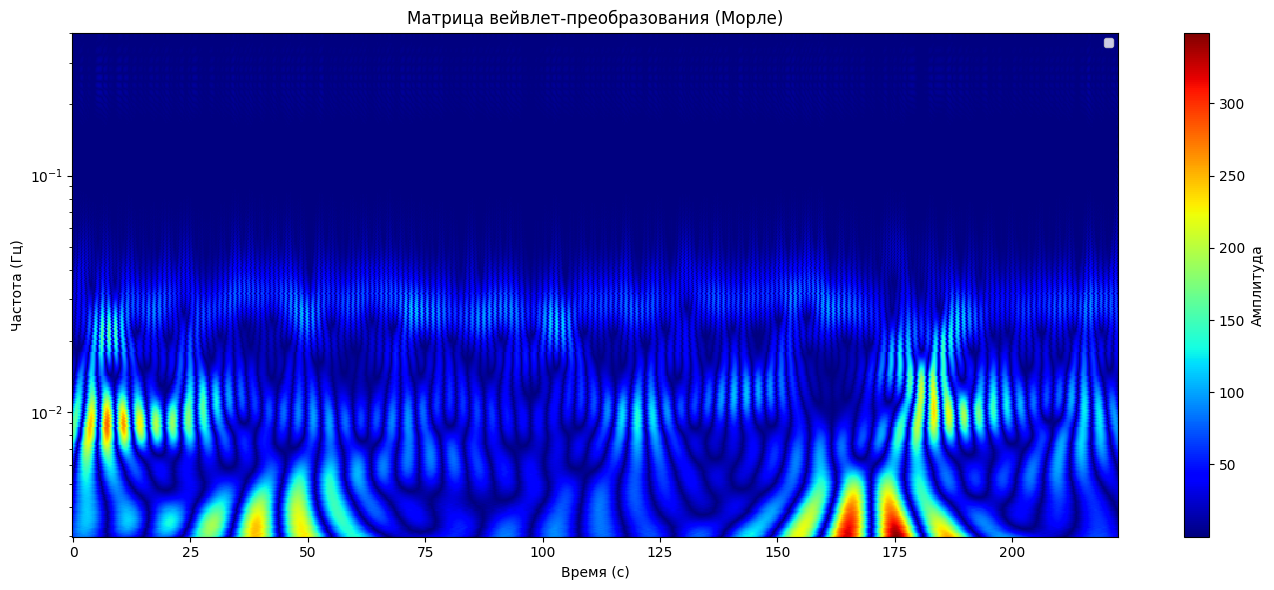

In [29]:
plt.figure(figsize=(14, 6))
plt.pcolormesh(t_uniform, F, np.abs(cwt_matrix), cmap='jet', shading='auto')
plt.colorbar(label='Амплитуда')
plt.yscale('log')
plt.legend(loc='upper right', fontsize=8)
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Матрица вейвлет-преобразования (Морле)')
plt.tight_layout()
plt.show()



# from mpl_toolkits.mplot3d import Axes3D

# T_mesh, F_mesh = np.meshgrid(t_uniform, F)
# fig = plt.figure(figsize=(14, 8))
# ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(T_mesh, F_mesh, np.abs(cwt_matrix), cmap='jet', rstride=2, cstride=10)
# ax.set_xlabel('Время (с)')
# ax.set_ylabel('Частота (Гц)')
# ax.set_zlabel('Амплитуда')
# ax.set_title('3D вейвлет-спектр (Морле)')
# plt.tight_layout()
# plt.show()


In [6]:
hf_idx = (F >= 0.15) & (F <= 0.4)
lf_idx = (F >= 0.04) & (F < 0.15)
vlf_idx = (F >= 0.003) & (F < 0.04)

HFt = np.sum(icwt_matrix[hf_idx], axis=0)
LFt = np.sum(icwt_matrix[lf_idx], axis=0)
VLFt = np.sum(icwt_matrix[vlf_idx], axis=0)


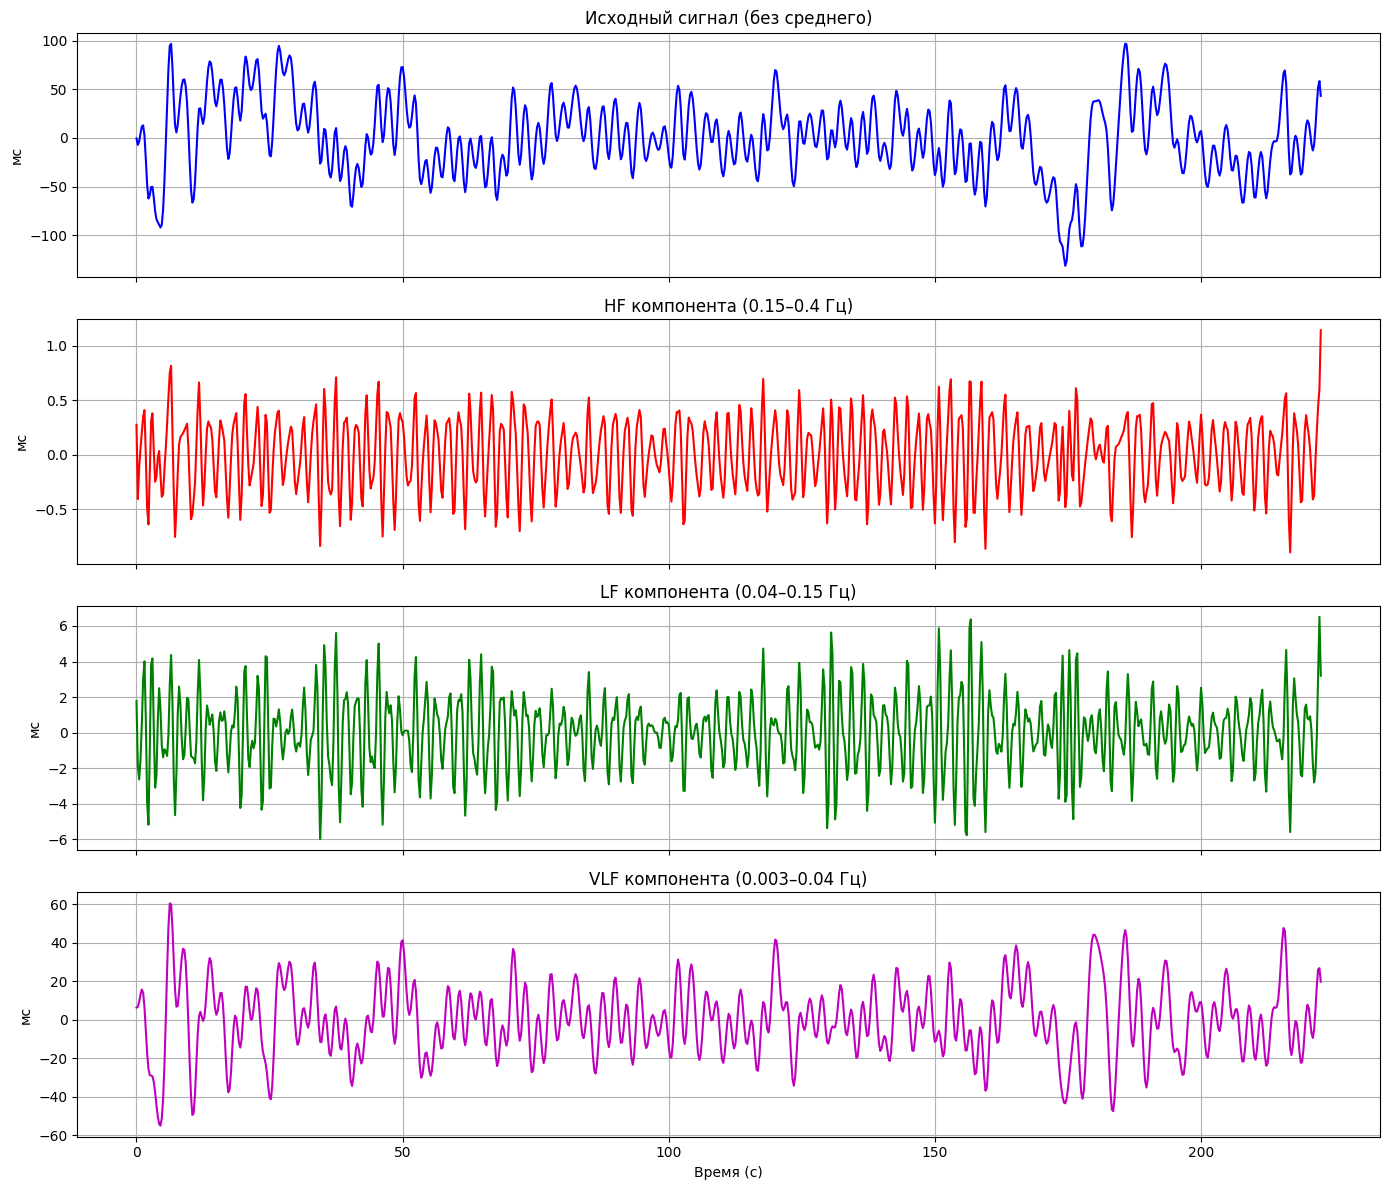

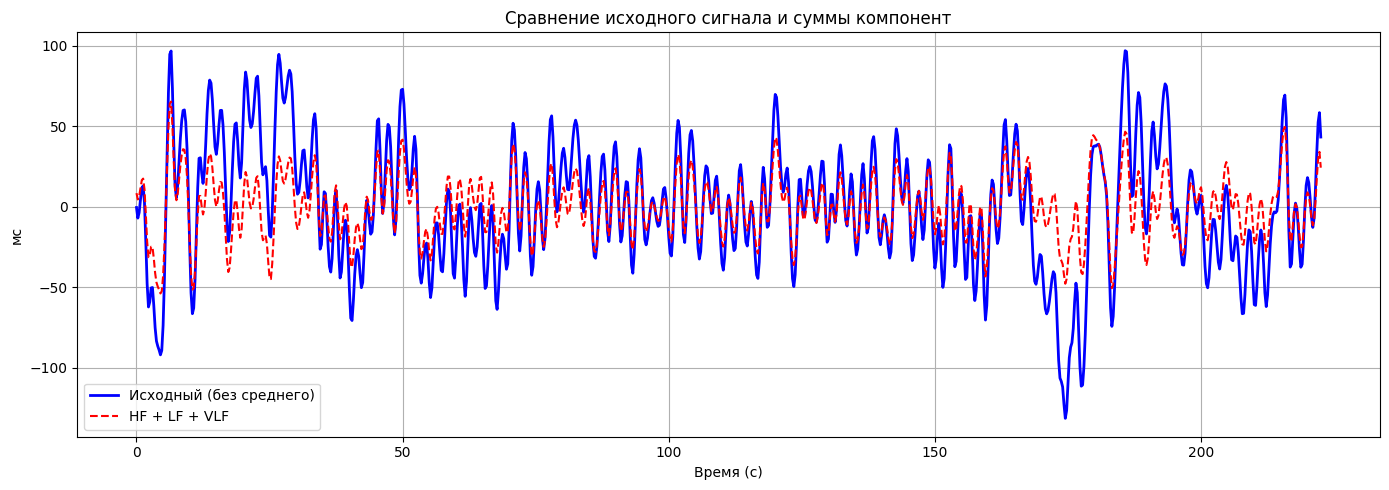

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t_uniform, signal_interp - np.mean(signal_interp), 'b')
axes[0].set_ylabel('мс')
axes[0].set_title('Исходный сигнал (без среднего)')
axes[0].grid(True)

axes[1].plot(t_uniform, HFt, 'r')
axes[1].set_ylabel('мс')
axes[1].set_title('HF компонента (0.15–0.4 Гц)')
axes[1].grid(True)

axes[2].plot(t_uniform, LFt, 'g')
axes[2].set_ylabel('мс')
axes[2].set_title('LF компонента (0.04–0.15 Гц)')
axes[2].grid(True)

axes[3].plot(t_uniform, VLFt, 'm')
axes[3].set_ylabel('мс')
axes[3].set_title('VLF компонента (0.003–0.04 Гц)')
axes[3].set_xlabel('Время (с)')
axes[3].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(t_uniform, signal_interp - np.mean(signal_interp), 'b', label='Исходный (без среднего)', linewidth=2)
plt.plot(t_uniform, HFt + LFt + VLFt, 'r--', label='HF + LF + VLF', linewidth=1.5)
plt.xlabel('Время (с)')
plt.ylabel('мс')
plt.title('Сравнение исходного сигнала и суммы компонент')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
power_per_scale = np.mean(np.abs(cwt_matrix)**2, axis=1) * dA_scales / A_scales**2

HF_power = np.sum(power_per_scale[hf_idx])
LF_power = np.sum(power_per_scale[lf_idx])
VLF_power = np.sum(power_per_scale[vlf_idx])
TP = HF_power + LF_power + VLF_power

HFn = HF_power / TP * 100
LFn = LF_power / TP * 100
VLFn = VLF_power / TP * 100

LF_HF = LF_power / HF_power

SDHF = np.std(HFt)
SDLF = np.std(LFt)
SDVLF = np.std(VLFt)
SDTP = np.std(HFt + LFt + VLFt)

params = pd.DataFrame({
    'Параметр': ['HF (мс²)', 'LF (мс²)', 'VLF (мс²)', 'TP (мс²)',
                 'HF (%)', 'LF (%)', 'VLF (%)',
                 'LF/HF',
                 'SDHF (мс)', 'SDLF (мс)', 'SDVLF (мс)', 'SDTP (мс)'],
    'Значение': [f'{HF_power:.2f}', f'{LF_power:.2f}', f'{VLF_power:.2f}', f'{TP:.2f}',
                 f'{HFn:.2f}', f'{LFn:.2f}', f'{VLFn:.2f}',
                 f'{LF_HF:.4f}',
                 f'{SDHF:.2f}', f'{SDLF:.2f}', f'{SDVLF:.2f}', f'{SDTP:.2f}']
})

print(params.to_string(index=False))


  Параметр Значение
  HF (мс²)     5.66
  LF (мс²)    10.41
 VLF (мс²)   488.97
  TP (мс²)   505.05
    HF (%)     1.12
    LF (%)     2.06
   VLF (%)    96.82
     LF/HF   1.8396
 SDHF (мс)     0.32
 SDLF (мс)     2.01
SDVLF (мс)    18.24
 SDTP (мс)    19.27


    Вейвлет  HF (мс²)  LF (мс²)  VLF (мс²)  TP (мс²)  HF (%)  LF (%)  VLF (%)   LF/HF
       morl      5.66     10.41     488.97    505.05    1.12    2.06    96.82  1.8396
      gaus5      9.99     35.82     866.94    912.76    1.09    3.92    94.98  3.5852
      gaus7      8.86     22.50     733.78    765.14    1.16    2.94    95.90  2.5399
      gaus8      8.29     11.18     672.74    692.20    1.20    1.62    97.19  1.3486
cmor1.5-1.0      1.66      2.09     141.48    145.23    1.14    1.44    97.42  1.2604
cmor1.5-2.0      0.81      0.42      68.15     69.38    1.17    0.60    98.23  0.5133
       mexh     18.12    262.04    2038.63   2318.80    0.78   11.30    87.92 14.4602


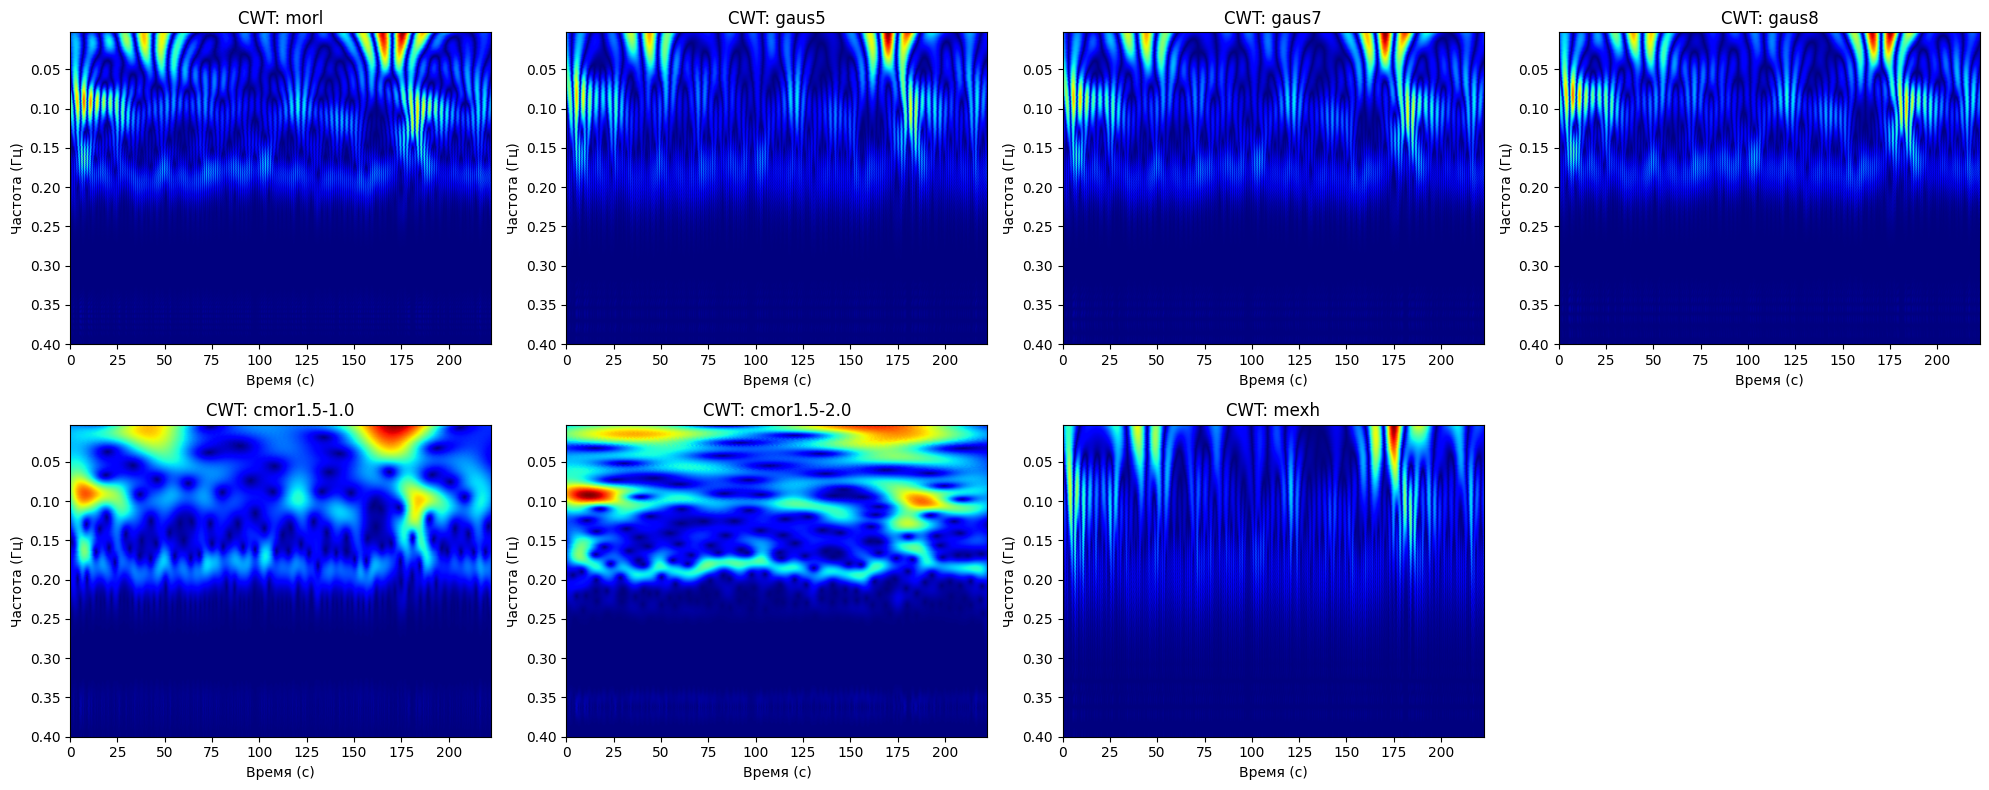

In [30]:
wavelets_list = ['morl', 'gaus5', 'gaus7', 'gaus8', 'cmor1.5-1.0', 'cmor1.5-2.0', 'mexh']
results = []

for wv in wavelets_list:
    try:
        cwt_m, icwt_m, F_w, A_w, dA_w = get_wavelets(signal_interp, wv, f1, f2, D)

        hf_idx = (F_w >= 0.15) & (F_w <= 0.4)
        lf_idx = (F_w >= 0.04) & (F_w < 0.15)
        vlf_idx = (F_w >= 0.003) & (F_w < 0.04)

        pps = np.mean(np.abs(cwt_m)**2, axis=1) * dA_w / A_w**2

        hf_p = np.sum(pps[hf_idx])
        lf_p = np.sum(pps[lf_idx])
        vlf_p = np.sum(pps[vlf_idx])
        tp = hf_p + lf_p + vlf_p
        lf_hf = lf_p / hf_p if hf_p > 0 else np.inf

        results.append({
            'Вейвлет': wv,
            'HF (мс²)': round(hf_p, 2),
            'LF (мс²)': round(lf_p, 2),
            'VLF (мс²)': round(vlf_p, 2),
            'TP (мс²)': round(tp, 2),
            'HF (%)': round(hf_p / tp * 100, 2),
            'LF (%)': round(lf_p / tp * 100, 2),
            'VLF (%)': round(vlf_p / tp * 100, 2),
            'LF/HF': round(lf_hf, 4)
        })
    except Exception as e:
        results.append({
            'Вейвлет': wv,
            'HF (мс²)': str(e),
            'LF (мс²)': '-',
            'VLF (мс²)': '-',
            'TP (мс²)': '-',
            'HF (%)': '-',
            'LF (%)': '-',
            'VLF (%)': '-',
            'LF/HF': '-'
        })

df_compare = pd.DataFrame(results)
print(df_compare.to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, wv in enumerate(wavelets_list):
    try:
        cwt_m, _, F_w, _, _ = get_wavelets(signal_interp, wv, f1, f2, D)
        axes[i].imshow(np.abs(cwt_m), cmap='jet', aspect='auto',
                       extent=[t_uniform[0], t_uniform[-1], F_w[-1], F_w[0]])
        axes[i].set_title(f'CWT: {wv}')
        axes[i].set_xlabel('Время (с)')
        axes[i].set_ylabel('Частота (Гц)')
    except Exception:
        axes[i].set_title(f'{wv}: ошибка')

if len(wavelets_list) < len(axes):
    for j in range(len(wavelets_list), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()


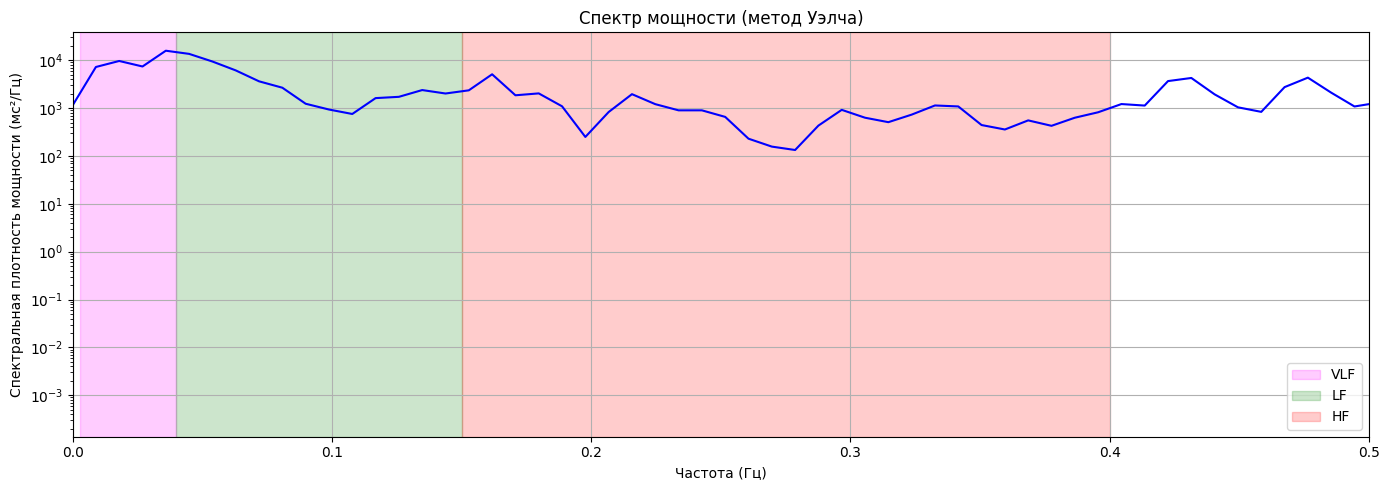

          Метод  HF (мс²)  LF (мс²)  VLF (мс²)  TP (мс²)  HF (%)  LF (%)  VLF (%)  LF/HF
Вейвлет (Морле)      5.66     10.41     488.97    505.05    1.12    2.06    96.82 1.8396
   Фурье (Уэлч)    240.56    344.93     257.64    843.12   28.53   40.91    30.56 1.4339


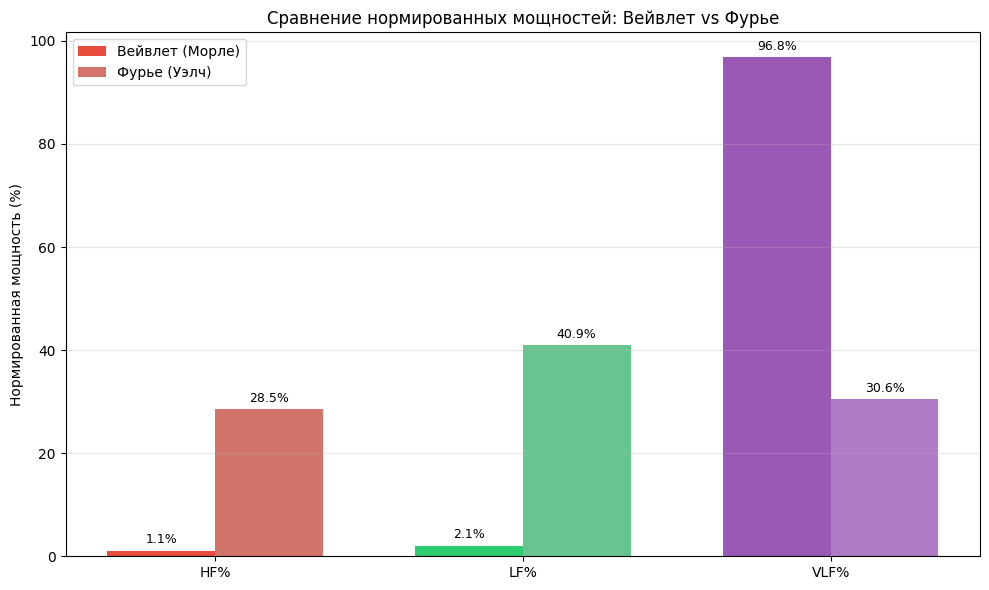

In [10]:
signal_centered = signal_interp - np.mean(signal_interp)
freqs_welch, psd_welch = welch(signal_centered, fs=D, nperseg=len(signal_centered) // 2, noverlap=len(signal_centered) // 4)

hf_mask = (freqs_welch >= 0.15) & (freqs_welch <= 0.4)
lf_mask = (freqs_welch >= 0.04) & (freqs_welch < 0.15)
vlf_mask = (freqs_welch >= 0.003) & (freqs_welch < 0.04)

HF_fft = trapezoid(psd_welch[hf_mask], freqs_welch[hf_mask])
LF_fft = trapezoid(psd_welch[lf_mask], freqs_welch[lf_mask])
VLF_fft = trapezoid(psd_welch[vlf_mask], freqs_welch[vlf_mask])
TP_fft = HF_fft + LF_fft + VLF_fft

LF_HF_fft = LF_fft / HF_fft if HF_fft > 0 else np.inf

plt.figure(figsize=(14, 5))
plt.semilogy(freqs_welch, psd_welch, 'b')
plt.axvspan(0.003, 0.04, alpha=0.2, color='magenta', label='VLF')
plt.axvspan(0.04, 0.15, alpha=0.2, color='green', label='LF')
plt.axvspan(0.15, 0.4, alpha=0.2, color='red', label='HF')
plt.xlabel('Частота (Гц)')
plt.ylabel('Спектральная плотность мощности (мс²/Гц)')
plt.title('Спектр мощности (метод Уэлча)')
plt.legend()
plt.grid(True)
plt.xlim([0, 0.5])
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Метод': ['Вейвлет (Морле)', 'Фурье (Уэлч)'],
    'HF (мс²)': [round(HF_power, 2), round(HF_fft, 2)],
    'LF (мс²)': [round(LF_power, 2), round(LF_fft, 2)],
    'VLF (мс²)': [round(VLF_power, 2), round(VLF_fft, 2)],
    'TP (мс²)': [round(TP, 2), round(TP_fft, 2)],
    'HF (%)': [round(HFn, 2), round(HF_fft / TP_fft * 100, 2)],
    'LF (%)': [round(LFn, 2), round(LF_fft / TP_fft * 100, 2)],
    'VLF (%)': [round(VLFn, 2), round(VLF_fft / TP_fft * 100, 2)],
    'LF/HF': [round(LF_HF, 4), round(LF_HF_fft, 4)]
})

print(comparison.to_string(index=False))

HFn_welch = HF_fft / TP_fft * 100
LFn_welch = LF_fft / TP_fft * 100
VLFn_welch = VLF_fft / TP_fft * 100

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35
bars_wavelet = [HFn, LFn, VLFn]
bars_fourier = [HFn_welch, LFn_welch, VLFn_welch]
rects1 = ax.bar(x - width/2, bars_wavelet, width, label='Вейвлет (Морле)', color=['#e74c3c', '#2ecc71', '#9b59b6'])
rects2 = ax.bar(x + width/2, bars_fourier, width, label='Фурье (Уэлч)', color=['#c0392b', '#27ae60', '#8e44ad'], alpha=0.7)
ax.set_ylabel('Нормированная мощность (%)')
ax.set_title('Сравнение нормированных мощностей: Вейвлет vs Фурье')
ax.set_xticks(x)
ax.set_xticklabels(['HF%', 'LF%', 'VLF%'])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Вейвлет-анализ

HF (0.15-0.4 Гц): 5.66 мс² (1.12%)
LF (0.04-0.15 Гц): 10.41 мс² (2.06%)
VLF (0.003-0.04 Гц): 488.97 мс² (96.82%)
TP: 505.05 мс²
LF/HF: 1.84
SDHF: 0.32 мс, SDLF: 2.01 мс, SDVLF: 18.24 мс, SDTP: 19.27 мс

# Спектральный анализ

HF (0.15-0.4 Гц): 240.56 мс² (28.53%)
LF (0.04-0.15 Гц): 344.93 мс² (40.91%)
VLF (0.003-0.04 Гц): 257.64 мс² (30.56%)
TP: 843.12 мс²
LF/HF: 1.43

# Статистические показатели ВСР

HR = 80.6 уд/мин, SDNN = 38.7 мс, RMSSD = 37.4 мс, pNN50 = 19%
Mo = 725 мс, SI = 13 у.е., MxDMn = 229 мс
CC1 = 0.53, CC0 = 11